In [92]:
!pip install numpy pandas matplotlib seaborn scikit-learn
!pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 15.9 MB/s eta 0:00:000:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 3.8 MB/s eta 0:00:00 0:00:010:00:01


In [121]:
import sys
print(sys.executable)


/opt/conda/envs/anaconda-2024.02-py310/bin/python


In [122]:
import sys
!{sys.executable} -m pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [127]:
import sys
sys.path.append("/home/efc8b3cf-3dea-4817-a066-1bfaa9e04f4e/.local/lib/python3.10/site-packages")

from xgboost import XGBClassifier


In [128]:
from xgboost import XGBClassifier


In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [98]:
raw_train = pd.read_csv(r"train_A_derma.csv", header=0)
raw_test  = pd.read_csv(r"test_A_derma.csv", header=0)

print("\n--- Raw heads ---")
print("Train head:")
display(raw_train.head(5))
print("Train shape:", raw_train.shape)
print("\nTest head:")
display(raw_test.head(5))
print("Test shape:", raw_test.shape)


--- Raw heads ---
Train head:


,Id,Lession,Genetic Propensity,Skin X test,Skin color,Small size,Mid size,Large size,Mid,Small,Large,Doughnuts consumption,Fake/Real
0,0,1.0,-1.27713,4.0,NaN,0.0,NaN,0.0,1.0,NaN,NaN,1.234125,real
1,1,NaN,-1.84207,3.0,0.0,1.0,0.0,0.0,0.0,1.0,NaN,1.216756,real
2,2,NaN,-1.82290,3.0,NaN,0.0,NaN,NaN,1.0,0.0,NaN,1.264342,real
3,3,1.0,-1.36049,3.0,NaN,1.0,0.0,0.0,0.0,1.0,0.0,1.126842,real
4,4,NaN,NaN,2.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,0.198014,fake


Train shape: (597, 13)

Test head:


,Id,Lession,Genetic Propensity,Skin X test,Skin color,Small size,Mid size,Large size,Mid,Small,Large,Doughnuts consumption
0,0,NaN,NaN,3.0,NaN,0.0,NaN,0.0,0.0,NaN,1.0,0.037404
1,1,NaN,NaN,3.0,1.0,1.0,0.0,0.0,NaN,1.0,0.0,0.052498
2,2,0.0,NaN,4.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0,0.276532
3,3,0.0,NaN,2.0,1.0,NaN,1.0,NaN,1.0,NaN,0.0,0.136218
4,4,1.0,-1.84207,4.0,1.0,0.0,1.0,0.0,1.0,NaN,NaN,0.099461


Test shape: (256, 12)


In [99]:
raw_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Id                     597 non-null    int64  
 1   Lession                407 non-null    float64
 2   Genetic Propensity     403 non-null    float64
 3   Skin X test            422 non-null    float64
 4   Skin color             420 non-null    float64
 5   Small size             413 non-null    float64
 6   Mid size               424 non-null    float64
 7   Large size             417 non-null    float64
 8   Mid                    422 non-null    float64
 9   Small                  413 non-null    float64
 10  Large                  407 non-null    float64
 11  Doughnuts consumption  597 non-null    float64
 12  Fake/Real              597 non-null    object 
dtypes: float64(11), int64(1), object(1)
memory usage: 60.8+ KB


In [100]:
raw_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Id                     256 non-null    int64  
 1   Lession                176 non-null    float64
 2   Genetic Propensity     171 non-null    float64
 3   Skin X test            189 non-null    float64
 4   Skin color             180 non-null    float64
 5   Small size             181 non-null    float64
 6   Mid size               176 non-null    float64
 7   Large size             178 non-null    float64
 8   Mid                    174 non-null    float64
 9   Small                  180 non-null    float64
 10  Large                  176 non-null    float64
 11  Doughnuts consumption  256 non-null    float64
dtypes: float64(11), int64(1)
memory usage: 24.1 KB


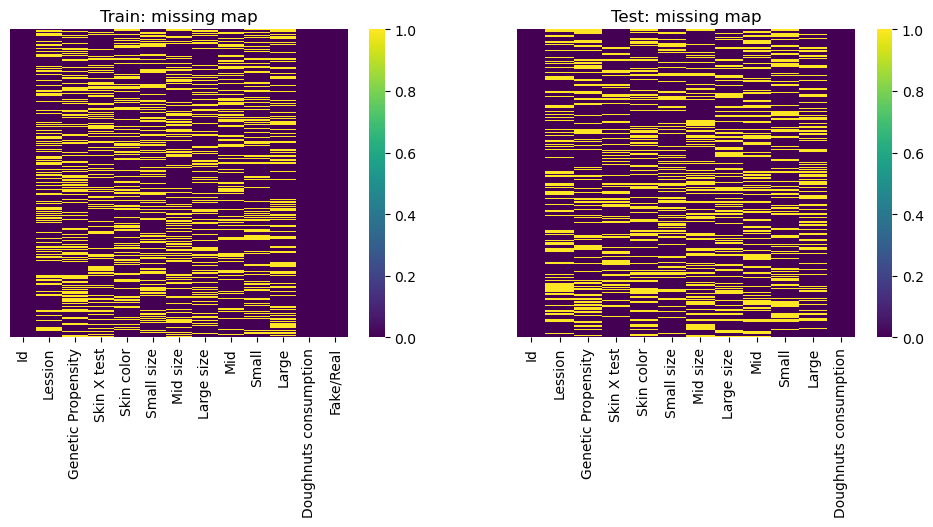

In [101]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.heatmap(raw_train.isnull(),yticklabels=False,cmap='viridis')
plt.title("Train: missing map")
plt.subplot(1,2,2)
sns.heatmap(raw_test.isnull(),yticklabels=False,cmap='viridis')
plt.title("Test: missing map")
plt.show()

In [102]:
labels_train = raw_train['Fake/Real']
features_train = raw_train.drop(columns=['Id','Fake/Real'])

labels_train = raw_train['Fake/Real'].map({"fake":0,"real":1})
print(labels_train.value_counts())

Fake/Real
0    344
1    253
Name: count, dtype: int64


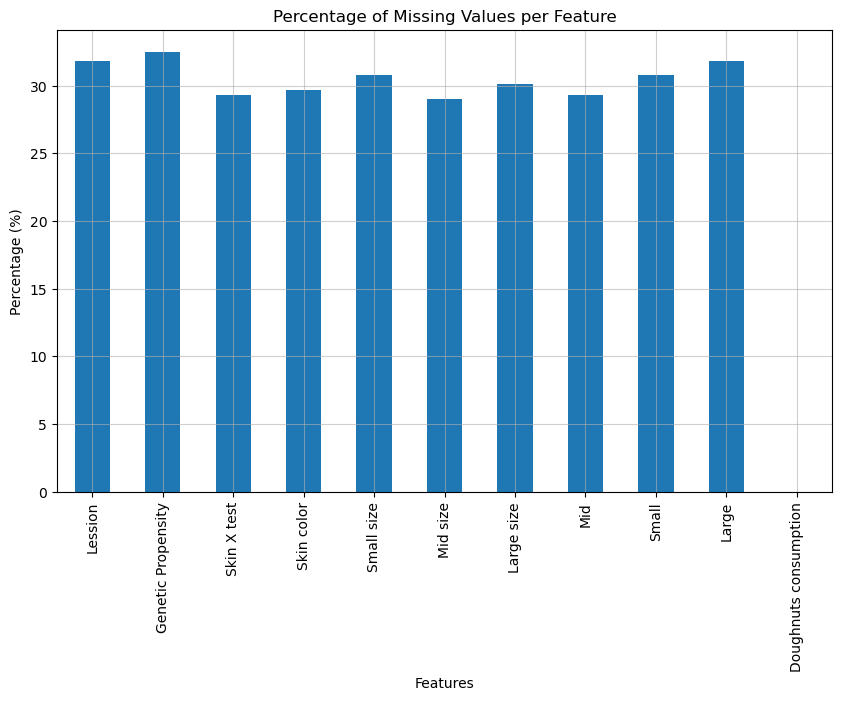

In [103]:
missing_percent = (features_train.isnull().sum() / len(features_train)) * 100
plt.figure(figsize=(10,6))
missing_percent.plot(kind='bar')
plt.title("Percentage of Missing Values per Feature")
plt.ylabel("Percentage (%)")
plt.xlabel("Features")
plt.grid(True,alpha=0.6)
plt.show()


In [104]:
print("Number of duplicated rows in training data:", features_train.duplicated().sum())

Number of duplicated rows in training data: 0


In [105]:
features_train.columns

Index(['Lession', 'Genetic Propensity', 'Skin X test', 'Skin color',
       'Small size', 'Mid size', 'Large size', 'Mid', 'Small', 'Large',
       'Doughnuts consumption'],
      dtype='object')

## 3NN ##

In [106]:
# 1. 标签
y_train = raw_train['Fake/Real'].map({"fake": 0, "real": 1})

# 2. 特征
X_train = raw_train.drop(columns=['Id', 'Fake/Real'])
X_test  = raw_test.drop(columns=['Id'])

In [107]:
# 3. standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. 3NN imputation missing value
imputer = KNNImputer(n_neighbors=3)
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed  = imputer.transform(X_test_scaled)

# 5. back to DataFrame，save cloumns name and index
X_train_imputed = pd.DataFrame(X_train_imputed,
                               columns=X_train.columns,
                               index=X_train.index)

X_test_imputed = pd.DataFrame(X_test_imputed,
                              columns=X_test.columns,
                              index=X_test.index)

print("Train processed shape:", X_train_imputed.shape)
print("Test processed shape:", X_test_imputed.shape)
print(X_train_imputed.isnull().sum())  # ensure no missing

Train processed shape: (597, 11)
Test processed shape: (256, 11)
Lession                  0
Genetic Propensity       0
Skin X test              0
Skin color               0
Small size               0
Mid size                 0
Large size               0
Mid                      0
Small                    0
Large                    0
Doughnuts consumption    0
dtype: int64


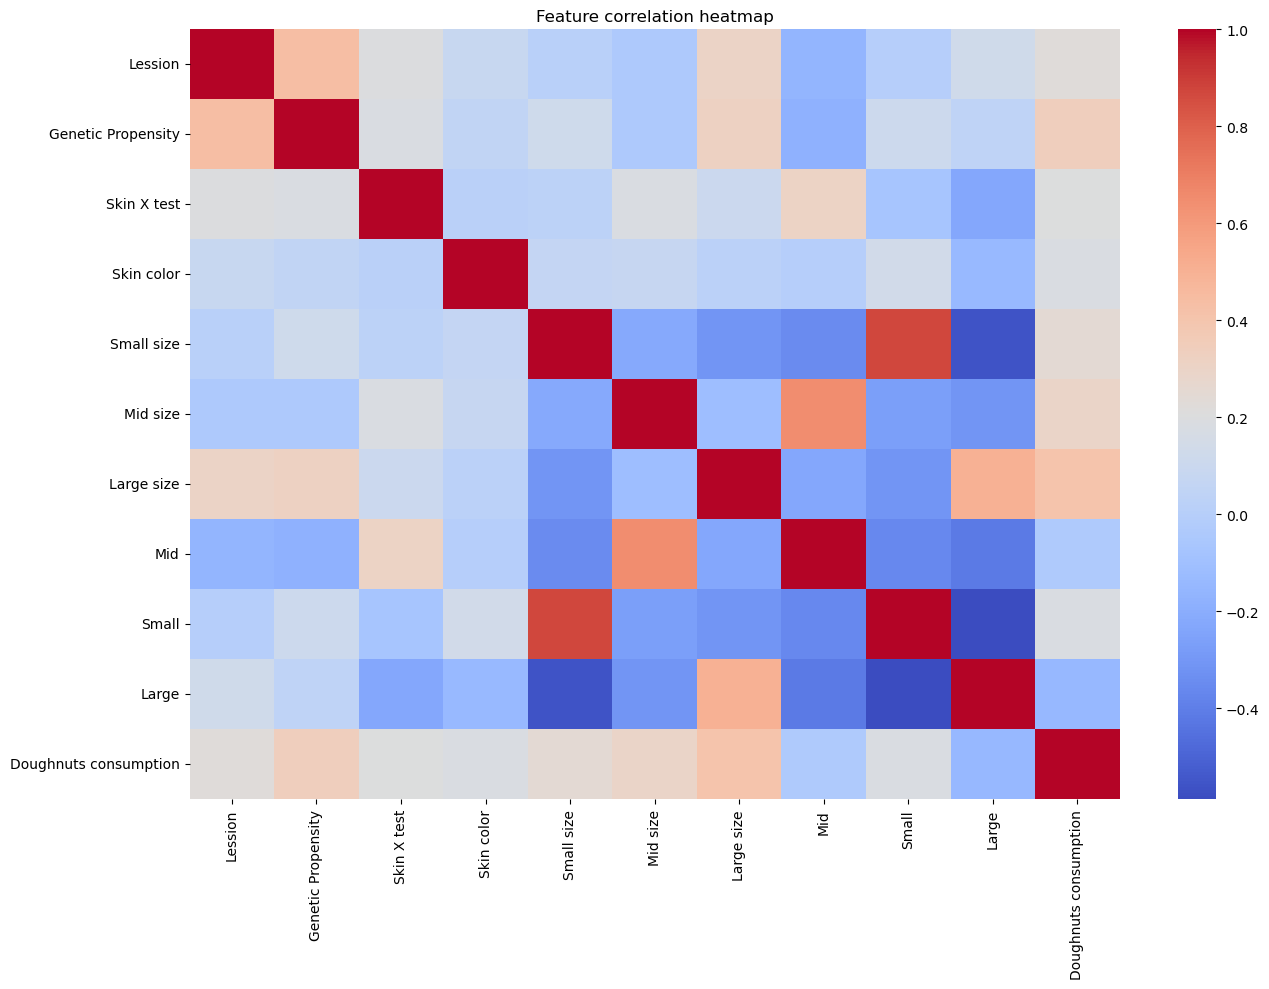

In [108]:
plt.figure(figsize=(15, 10))
sns.heatmap(X_train_imputed.corr(), cmap="coolwarm")
plt.title("Feature correlation heatmap")
plt.show()


In [109]:
def run_svm_gridsearch(X, y, kernel, param_grid, cv_splits=5):
    """
    Run GridSearchCV for an SVM with a given kernel.
    Returns the best estimator and its best cross-validated score.
    """
    print(f"\n===== Kernel = {kernel} grid search started =====")
    
    svm = SVC(kernel=kernel, probability=False)  # probability=True is much slower, usually not needed here
    
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    
    grid = GridSearchCV(
        estimator=svm,
        param_grid=param_grid,
        scoring='accuracy',      
        cv=cv,
        n_jobs=-1,               # use all available CPU cores
        verbose=1
    )
    
    grid.fit(X, y)
    
    print(f"\nBest params: {grid.best_params_}")
    print(f"Best CV mean accuracy: {grid.best_score_:.4f}")
    
    return grid.best_estimator_, grid.best_score_


In [110]:
# RBF kernel parameter grid
rbf_param_grid = {
    'C': [0.1, 1, 10, 100],         # regularization strength
    'gamma': ['scale', 'auto', 0.01, 0.1, 1.0]  # kernel width
}

X_train = X_train_imputed
X_test  = X_test_imputed

best_rbf_svm, best_rbf_score = run_svm_gridsearch(
    X=X_train,
    y=y_train,
    kernel='rbf',
    param_grid=rbf_param_grid,
    cv_splits=5
)



===== Kernel = rbf grid search started =====
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params: {'C': 1, 'gamma': 0.01}
Best CV mean accuracy: 1.0000


In [111]:
# Polynomial kernel parameter grid
poly_param_grid = {
    'C': [0.1, 1, 10],
    'degree': [2, 3, 4],          
    'gamma': ['scale', 'auto'],  
    'coef0': [0.0, 1.0]           
}

best_poly_svm, best_poly_score = run_svm_gridsearch(
    X=X_train,
    y=y_train,
    kernel='poly',
    param_grid=poly_param_grid,
    cv_splits=5
)



===== Kernel = poly grid search started =====
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params: {'C': 0.1, 'coef0': 1.0, 'degree': 2, 'gamma': 'scale'}
Best CV mean accuracy: 1.0000


In [112]:
corrs = pd.concat([X_train_imputed, y_train], axis=1).corr()
corrs['Fake/Real'].sort_values(ascending=False)


Fake/Real                1.000000
Doughnuts consumption    0.984536
Large size               0.397820
Genetic Propensity       0.328441
Mid size                 0.308483
Small size               0.256099
Skin X test              0.217174
Lession                  0.208237
Small                    0.187540
Skin color               0.185443
Mid                     -0.020341
Large                   -0.154281
Name: Fake/Real, dtype: float64

In [113]:
from sklearn.metrics import accuracy_score

for col in X_train_imputed.columns:
    pred = (X_train_imputed[col] > np.nanmedian(X_train_imputed[col])).astype(int)
    acc = accuracy_score(y_train, pred)
    if acc > 0.9:
        print(col, acc)


Doughnuts consumption 0.9246231155778895


In [114]:
X_train_clean = X_train_imputed.drop(columns=["Doughnuts consumption"])
X_test_clean  = X_test_imputed.drop(columns=["Doughnuts consumption"])

print("Clean train shape:", X_train_clean.shape)
print("Missing:", X_train_clean.isnull().sum().sum())

Clean train shape: (597, 10)
Missing: 0


In [115]:
rbf_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1.0]
}

best_rbf_svm, best_rbf_score = run_svm_gridsearch(
    X=X_train_clean,
    y=y_train,
    kernel='rbf',
    param_grid=rbf_param_grid,
    cv_splits=5
)



===== Kernel = rbf grid search started =====
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params: {'C': 10, 'gamma': 0.01}
Best CV mean accuracy: 0.8794


In [116]:
poly_param_grid = {
    'C': [0.1, 1, 10],
    'degree': [2, 3, 4],
    'gamma': ['scale', 'auto'],
    'coef0': [0.0, 1.0]
}

best_poly_svm, best_poly_score = run_svm_gridsearch(
    X=X_train_clean,
    y=y_train,
    kernel='poly',
    param_grid=poly_param_grid,
    cv_splits=5
)



===== Kernel = poly grid search started =====
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params: {'C': 0.1, 'coef0': 1.0, 'degree': 2, 'gamma': 'scale'}
Best CV mean accuracy: 0.8845


In [117]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_clean, y_train, 
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

model = best_rbf_svm  
model.fit(X_tr, y_tr)
val_pred = model.predict(X_val)

print("Validation accuracy:", accuracy_score(y_val, val_pred))
print(classification_report(y_val, val_pred))
 

Validation accuracy: 0.9083333333333333
              precision    recall  f1-score   support

           0       0.98      0.86      0.91        69
           1       0.83      0.98      0.90        51

    accuracy                           0.91       120
   macro avg       0.91      0.92      0.91       120
weighted avg       0.92      0.91      0.91       120



In [118]:
# Compare best RBF SVM vs best Poly SVM
# Keep the same validation split for fair comparison
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_clean, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

models = {
    "RBF SVM": best_rbf_svm,
    "Polynomial SVM": best_poly_svm
}

results = {}

for name, model in models.items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    acc = accuracy_score(y_val, pred)
    results[name] = acc

    print(f"\n===== {name} =====")
    print("Validation accuracy:", acc)
    print(classification_report(y_val, pred))

print("\n\n=== Comparison Summary ===")
for k, v in results.items():
    print(f"{k}: {v:.4f}")



===== RBF SVM =====
Validation accuracy: 0.9083333333333333
              precision    recall  f1-score   support

           0       0.98      0.86      0.91        69
           1       0.83      0.98      0.90        51

    accuracy                           0.91       120
   macro avg       0.91      0.92      0.91       120
weighted avg       0.92      0.91      0.91       120


===== Polynomial SVM =====
Validation accuracy: 0.9083333333333333
              precision    recall  f1-score   support

           0       0.98      0.86      0.91        69
           1       0.83      0.98      0.90        51

    accuracy                           0.91       120
   macro avg       0.91      0.92      0.91       120
weighted avg       0.92      0.91      0.91       120



=== Comparison Summary ===
RBF SVM: 0.9083
Polynomial SVM: 0.9083


In [119]:
# Random Forest baseline
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_tr, y_tr)
rf_pred = rf_model.predict(X_val)

print("\n===== Random Forest =====")
print("Validation accuracy:", accuracy_score(y_val, rf_pred))
print(classification_report(y_val, rf_pred))



===== Random Forest =====
Validation accuracy: 0.8916666666666667
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        69
           1       0.85      0.90      0.88        51

    accuracy                           0.89       120
   macro avg       0.89      0.89      0.89       120
weighted avg       0.89      0.89      0.89       120



In [131]:
# XGBoost baseline
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_tr, y_tr)
xgb_pred = xgb_model.predict(X_val)

print("\n===== XGBoost =====")
print("Validation accuracy:", accuracy_score(y_val, xgb_pred))
print(classification_report(y_val, xgb_pred))



===== XGBoost =====
Validation accuracy: 0.875
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        69
           1       0.83      0.88      0.86        51

    accuracy                           0.88       120
   macro avg       0.87      0.88      0.87       120
weighted avg       0.88      0.88      0.88       120



### Tree-based models such as Random Forest and XGBoost achieve strong performance (0.89 and 0.88 validation accuracy respectively), but the tuned RBF/Polynomial SVM slightly outperforms them (0.91), suggesting that a smooth kernel-based decision boundary is particularly well suited to this dataset ###